In [ ]:
#Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [123]:
#Importing File from local device folder

from google.colab import files
uploaded = files.upload()

Saving phishing_site_urls.csv to phishing_site_urls (2).csv


In [124]:
#Reading Dataset

df = pd.read_csv('phishing_site_urls.csv')

In [125]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [126]:
df.shape

(549346, 2)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 549346 entries, 0 to 549345
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   URL     549346 non-null  object
 1   Label   549346 non-null  object
dtypes: object(2)
memory usage: 8.4+ MB


In [128]:
# Checking for missing/null values in dataset

df.isnull().sum()

,0
URL,0
Label,0


In [129]:
# Checking distribution of phishing and legitimate labels

df.Label.value_counts()

,count
Label,
good,392924
bad,156422


In [130]:
# Importing tokenizer for URL text preprocessing

from nltk.tokenize import RegexpTokenizer

In [131]:
# Creating tokenizer for extracting words from URLs

tokenizer = RegexpTokenizer(r'[A-Za-z]+')

In [132]:
# Displaying first URL from dataset

df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [133]:
# Tokenizing first URL into meaningful words

tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [134]:
# Tokenizing all URLs in dataset

df['text_tokenized'] = df['URL'].apply(tokenizer.tokenize)

In [135]:
# Displaying updated dataset after tokenization

df.head()

,URL,Label,text_tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [136]:
# Importing stemmer for reducing words to root form

from nltk.stem.snowball import SnowballStemmer

In [137]:
# Initializing English stemmer

stemmer = SnowballStemmer('english')

In [138]:
# Applying stemming on tokenized URLs

df['text_stemmed'] = df['text_tokenized'].apply(lambda words: [stemmer.stem(word) for word in words])

In [139]:
# Displaying dataset after stemming

df.head()

,URL,Label,text_tokenized,text_stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [140]:
# Joining stemmed words into final text format

df['text'] = df['text_stemmed'].apply(lambda words: ' '.join(words))

In [141]:
# Displaying stemmed words in text format

df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [142]:
# Separating legitimate and phishing URLs

good_sites = df[df['Label'] == 'good']
bad_sites = df[df['Label'] == 'bad']

In [143]:
# Displaying sample legitimate URLs

good_sites.head()

,URL,Label,text_tokenized,text_stemmed,text
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [144]:
# Function to generate word cloud visualization

def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(24.0,16.0),
                   title = None, title_size=40, image_color=False):
    stopwords = set(STOPWORDS)
    more_stopwords = {'com','http'}
    stopwords = stopwords.union(more_stopwords)

    wordcloud = WordCloud(background_color='white',
                    stopwords = stopwords,
                    max_words = max_words,
                    max_font_size = max_font_size,
                    random_state = 42,
                    mask = mask)
    wordcloud.generate(text)

    plt.figure(figsize=figure_size)
    if image_color:
        image_colors = ImageColorGenerator(mask);
        plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
        plt.title(title, fontdict={'size': title_size,
                                  'verticalalignment': 'bottom'})
    else:
        plt.imshow(wordcloud, interpolation='bilinear');
        plt.title(title, fontdict={'size': title_size, 'color': 'green',
                                  'verticalalignment': 'bottom'})
    plt.axis('off');
    plt.tight_layout()

In [145]:
# Combining all legitimate URL text into one string

all_text = ' '.join(good_sites['text'].tolist())

In [146]:
# Importing WordCloud library for text visualization

from wordcloud import WordCloud

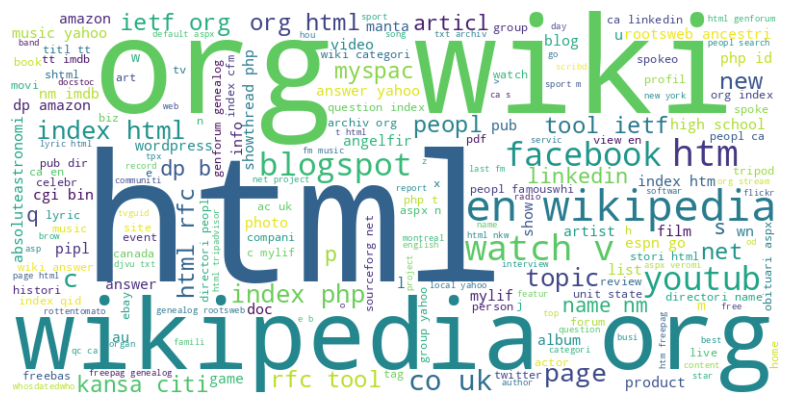

In [147]:
# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [148]:
# Combining all phishing URL text into one string

all_text= ' '.join(bad_sites['text'].tolist())

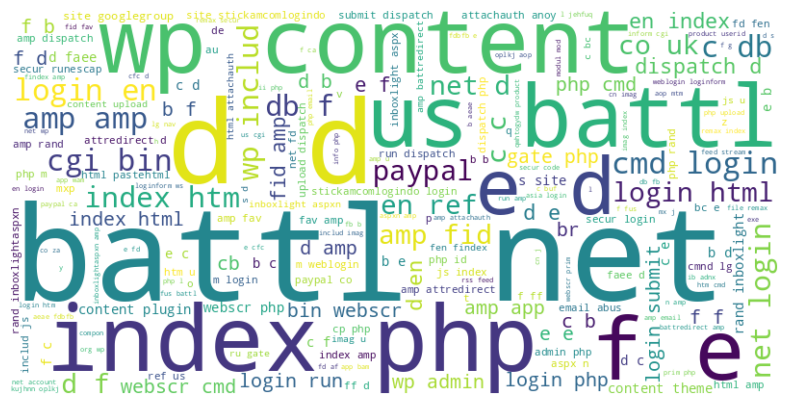

In [149]:
# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [150]:
# Displaying dataset after phishing URL analysis

df.head()

,URL,Label,text_tokenized,text_stemmed,text
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [151]:
# Importing CountVectorizer for text feature extraction

from sklearn.feature_extraction.text import TfidfVectorizer

In [152]:
# Initializing text vectorizer

cv = TfidfVectorizer()

In [153]:
# Converting text data into numerical features

features = cv.fit_transform(df['text'])

In [154]:
# Displaying first 5 numerical feature vectors

features[:5].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [155]:
# Importing function to split training and testing data

from sklearn.model_selection import train_test_split

In [156]:
# Splitting dataset into training and testing data

x_train, x_test, y_train, y_test = train_test_split(
    features,
    df['Label'],
    test_size=0.2,
    random_state=42
)

#Model Training

In [157]:
# Importing Logistic Regression model

from sklearn.linear_model import LogisticRegression

In [158]:
# Initializing Logistic Regression model

l_model = LogisticRegression(max_iter=1000)

In [159]:
# Training Logistic Regression model

l_model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [160]:
# Checking model accuracy on test data

accuracy = l_model.score(x_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9575134249567671


In [161]:
# Checking training accuracy of model

train_accuracy = l_model.score(x_train, y_train)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9677889122500433


In [162]:
# Importing classification report for model evaluation

from sklearn.metrics import classification_report

In [163]:
# Generating classification report for model performance

y_pred = l_model.predict(x_test)

print("\nCLASSIFICATION REPORT\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=['Bad', 'Good']
))


CLASSIFICATION REPORT

              precision    recall  f1-score   support

         Bad       0.96      0.88      0.92     31200
        Good       0.96      0.99      0.97     78670

    accuracy                           0.96    109870
   macro avg       0.96      0.94      0.95    109870
weighted avg       0.96      0.96      0.96    109870



In [164]:
# Importing confusion matrix for prediction analysis

from sklearn.metrics import confusion_matrix

In [165]:
# Creating confusion matrix table for prediction analysis

con_mat = pd.DataFrame(
    confusion_matrix(y_test, l_model.predict(x_test)),
    columns=['Predicted:Bad', 'Predicted:Good'],
    index=['Actual:Bad', 'Actual:Good'])


CONFUSION MATRIX


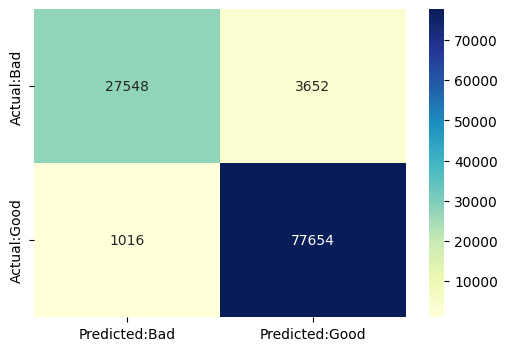

In [166]:
# Visualizing confusion matrix using heatmap

print('\nCONFUSION MATRIX')

plt.figure(figsize=(6,4))

sns.heatmap(
    con_mat,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.show()

In [167]:
# Importing Naive Bayes classification model

from sklearn.naive_bayes import MultinomialNB

In [168]:
# Initializing Naive Bayes model

mnb = MultinomialNB()

In [169]:
# Training Naive Bayes model

mnb.fit(x_train,y_train)

MultinomialNB()

In [170]:
# Checking Naive Bayes model accuracy

nb_accuracy = mnb.score(x_test, y_test)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9656412123418585


#Saving Model

In [171]:
# Importing pickle library for saving ML model

import pickle

In [172]:
# Saving trained phishing detection model

pickle.dump(l_model, open('model.pkl', 'wb'))

pickle.dump(cv, open('vectorizer.pkl', 'wb'))

In [173]:
# Saving final deployed Naive Bayes model

pickle.dump(mnb, open('phishing_mnb.pkl', 'wb'))
pickle.dump(cv, open('vectorizer.pkl', 'wb'))

In [174]:
# Sample phishing and legitimate URLs for testing

predict_bad = [
    'fake-bank-login-security.com',
    'verify-paypal-account-free.com',
    'secure-update-login.net'
]

predict_good = [
    'https://youtube.com',
    'https://github.com',
    'https://wikipedia.org'
]

In [175]:
# URL preprocessing function

def preprocess_url(url):

    # Tokenization
    tokens = tokenizer.tokenize(url)

    # Stemming
    stemmed = [stemmer.stem(word) for word in tokens]

    # Joining words
    processed_url = ' '.join(stemmed)

    return processed_url

In [176]:
# Preprocessing good URLs

good_processed = [preprocess_url(url) for url in predict_good]

# Preprocessing bad URLs

bad_processed = [preprocess_url(url) for url in predict_bad]

In [178]:
good_vector = cv.transform(good_processed)

bad_vector = cv.transform(bad_processed)

In [181]:
# Predicting labels for legitimate test URLs

mnb.predict(good_vector)

array(['good', 'bad', 'good'], dtype='<U4')

In [182]:
# Predicting labels for phishing test URLs

mnb.predict(bad_vector)

array(['bad', 'bad', 'bad'], dtype='<U4')

In [183]:
# Predicting labels for legitimate URLs using Naive Bayes model

mnb.predict(good_vector)

array(['good', 'bad', 'good'], dtype='<U4')

In [184]:
# Predicting labels for phishing URLs using Naive Bayes model

mnb.predict(bad_vector)

array(['bad', 'bad', 'bad'], dtype='<U4')